### Descomposicion y Pronostico Taller de Series de Tiempo

**Descripción**

Este conjunto de datos contiene información sobre la popularidad y el nivel de interés en diversos lenguajes de programación a lo largo del tiempo, medidos a partir del número total de preguntas realizadas en Stack Overflow entre los años 2008 y 2024.

El dataset permite analizar la evolución de los lenguajes de programación y comprender las tendencias y dinámicas cambiantes dentro del ecosistema del desarrollo de software. A través de estos datos, es posible identificar cómo varían las preferencias e intereses de los desarrolladores a nivel mundial, reflejando la adopción, crecimiento o declive de distintas tecnologías a lo largo de los años.

In [30]:
# vamos a leer la base de datos de Stack Overflow sobre preguntas de lenguajes de programación
import pandas as pd

# Leer el archivo CSV con los datos de Stack Overflow
df = pd.read_csv("TotalQuestions.csv")

# Mostrar las primeras filas del DataFrame
df.head()

,Month,C++,C#,TypeScript,PHP,Swift,Ruby,Go,SQL,Kotlin,...,Shell,C,HTML,Objective-C,Perl,Matlab,R,Python,Java,Javascript
0,2008-09-01,755,1639,0,474,0,286,0,503,0,...,65,320,328,50,130,11,6,537,634,1129
1,2008-11-01,734,1729,0,499,0,157,0,413,0,...,51,258,327,106,97,11,1,448,580,954
2,2008-12-01,630,1594,0,476,0,159,0,424,0,...,51,188,309,123,133,13,1,437,625,825
3,2009-01-01,848,2374,0,628,1,205,0,585,0,...,47,318,414,143,146,19,8,631,790,1147
4,2009-02-01,841,2597,0,757,1,286,0,668,0,...,75,331,480,209,163,27,8,630,945,1202


Vamos a interpretar nuestros datos

In [31]:
# numero total de registros
total_registros = df['Python'].count()
print(f"El número total de registros es: {total_registros}")
# temporalidades de la serie para python osea el rango de fechas
# fecha minima y maxima
fecha_minima = df['Month'].min()
fecha_maxima = df['Month'].max()
print(f"El rango de fechas para Python es: {fecha_minima} a {fecha_maxima}")

El número total de registros es: 185
El rango de fechas para Python es: 2008-09-01 a 2024-02-01


Osea tenemos fechas que van desde Noviembre de 2008 hasta Febrero de 2024. Ahora vamos a ajustar la temporalidad de los periodos. Solo tomemos el año y el mes de cada registro.


In [32]:
# primero saquemos una dt a parte solo con python para trabajar mas comodo
df_python = df[['Month', 'Python']].copy()
df_python.head()

,Month,Python
0,2008-09-01,537
1,2008-11-01,448
2,2008-12-01,437
3,2009-01-01,631
4,2009-02-01,630


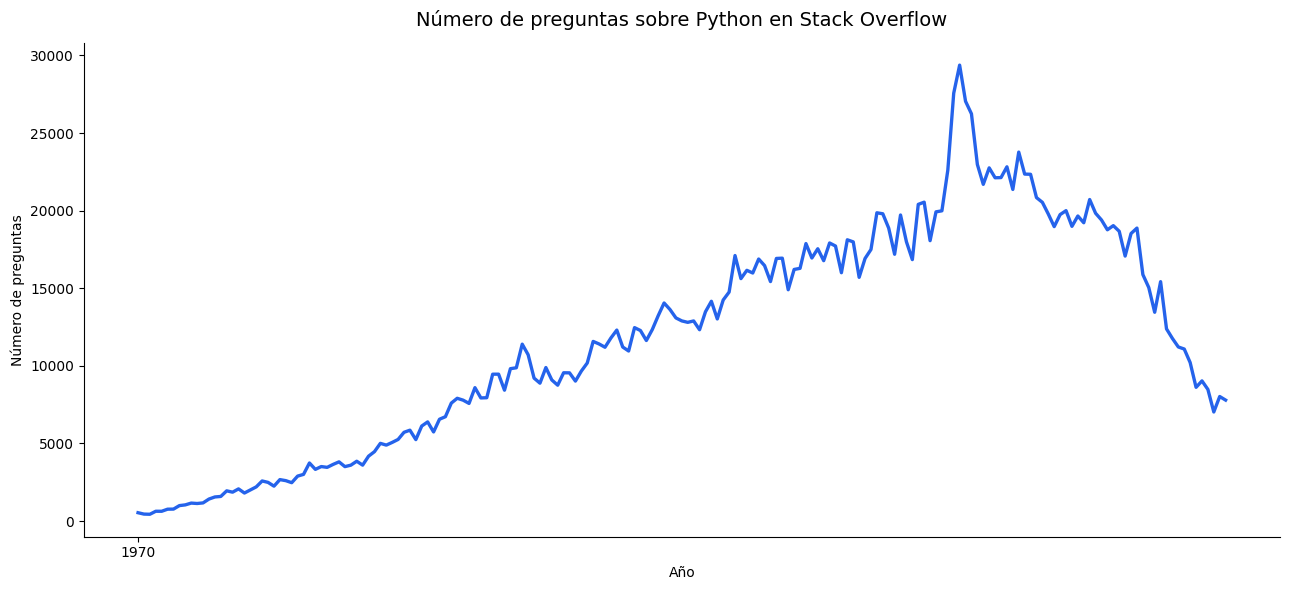

In [33]:
# bien ahora vamos a graficar la serie de tiempo con la nueva temporalida
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    df_python['Month'],
    df_python['Python'],
    color='#2563eb',
    linewidth=2.4
)

ax.set_title('Número de preguntas sobre Python en Stack Overflow', fontsize=14, pad=12)
ax.set_xlabel('Año')
ax.set_ylabel('Número de preguntas')

# formatear eje x para que muestre solo el año
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=0)

# limpieza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

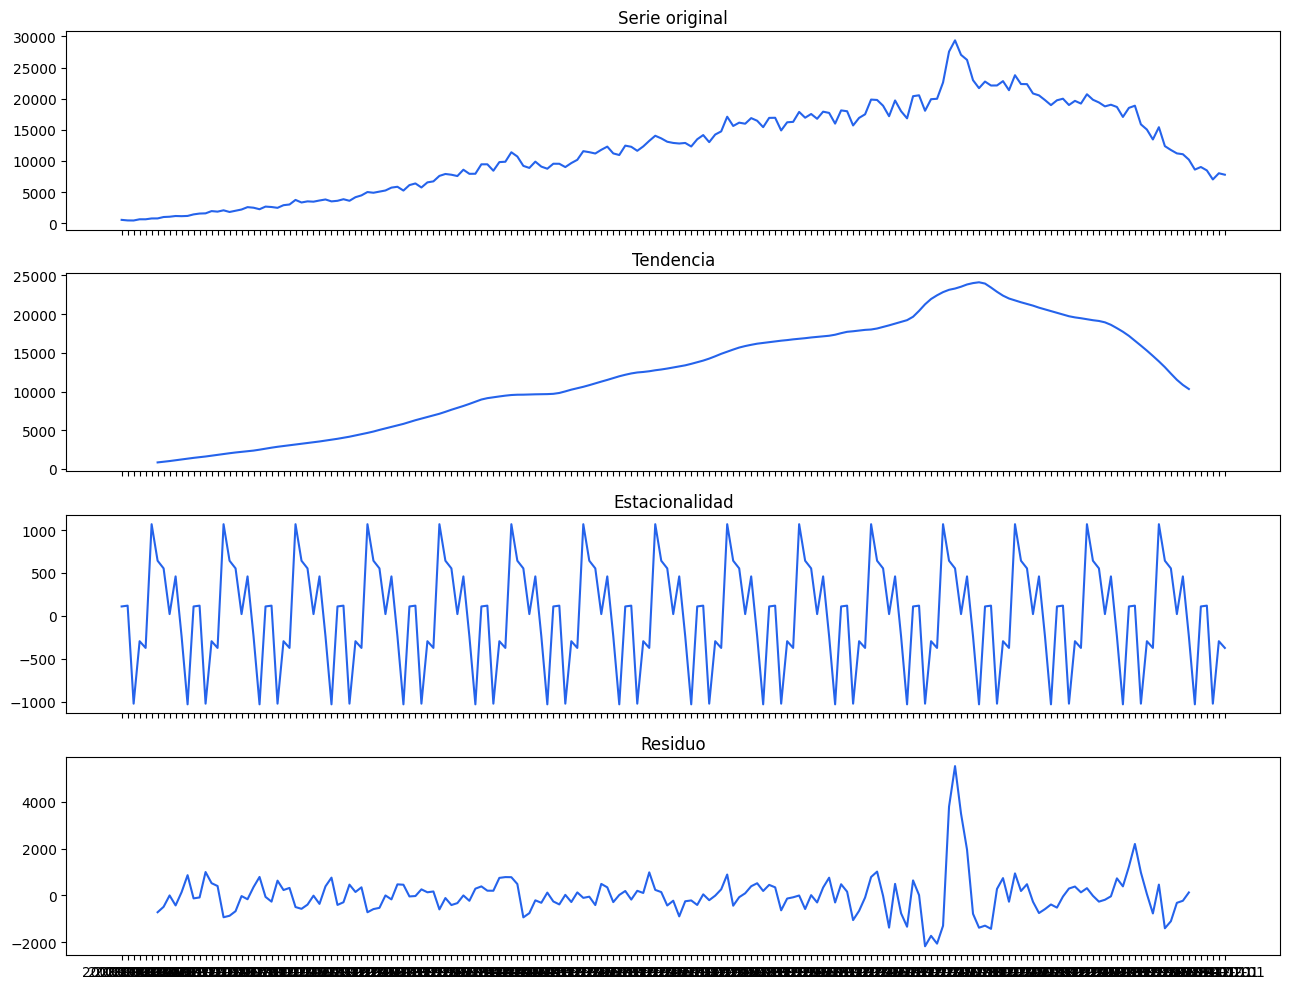

In [34]:
# ahora vamos a realizar una descomposición de la serie de tiempo
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición de la serie de tiempo
result = seasonal_decompose(df_python['Python'], model='additive', period=12)

# Graficar la descomposición
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

ax1.plot(df_python['Month'], df_python['Python'], color='#2563eb')
ax1.set_title('Serie original')

ax2.plot(df_python['Month'], result.trend, color='#2563eb')
ax2.set_title('Tendencia')

ax3.plot(df_python['Month'], result.seasonal, color='#2563eb')
ax3.set_title('Estacionalidad')

ax4.plot(df_python['Month'], result.resid, color='#2563eb')
ax4.set_title('Residuo')

plt.tight_layout()
plt.show()

De aqui se puede entender que la serie tiene una tendencia creciente hasta mitad de 2020 y luego parece disminuir ligeramente. Este pico en 2019 se puede interpretar como un aumento temporal en el interés por Python en Stack Overflow, posiblemente debido a eventos especificos como la pandemia que hizo que muchas personas se interesaran por aprender Python para tareas relacionadas con el análisis de datos, machine learning, etc. Sin embargo, después de ese pico, el interés parece estabilizarse o disminuir ligeramente, lo que podría tambien ser explicado por el boom de la IA en 2022 que es cuando se lanza oficialmente ChatGPT y muchas personas se interesan por aprender sobre IA y no tanto por Python en general.

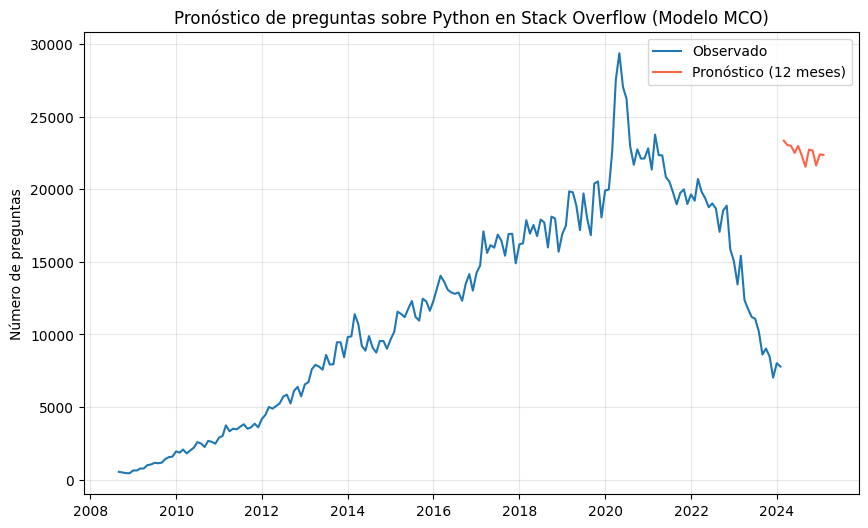

In [35]:
# Ajustar el modelo usando TSLM (Time Series Linear Model - MCO para series de tiempo)
# Ajustar el modelo usando OLS (equivalente a TSLM: tendencia lineal + estacionalidad)
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf #smf para usar formulas como en R
import matplotlib.pyplot as plt

# asegurar formato de fecha
df_python['Month'] = pd.to_datetime(df_python['Month'].astype(str))

# variables de tendencia y estacionalidad
df_python = df_python.sort_values("Month").copy()
# la variable de tendencia es simplemente un contador de los periodos
df_python["trend"] = np.arange(1, len(df_python) + 1)
# la variable de estacionalidad es el mes del año, que se convierte en una variable categórica
df_python["mes"] = df_python["Month"].dt.month.astype("category")

# Modelo lineal con estacionalidad fija
fit_mco = smf.ols("Python ~ trend + C(mes)", data=df_python).fit()

# Pronóstico a 12 meses
h = 12
ultimo_periodo = df_python["Month"].max()
futuro = pd.DataFrame({
  "Month": pd.date_range(ultimo_periodo + pd.offsets.MonthBegin(1), periods=h, freq="MS")
})
futuro["trend"] = np.arange(len(df_python) + 1, len(df_python) + h + 1)
futuro["mes"] = futuro["Month"].dt.month.astype("category")

pronostico = futuro.copy()
pronostico["prediccion"] = fit_mco.predict(futuro)

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_python["Month"], df_python["Python"], label="Observado")
plt.plot(pronostico["Month"], pronostico["prediccion"], label="Pronóstico (12 meses)", color="tomato")
plt.title("Pronóstico de preguntas sobre Python en Stack Overflow (Modelo MCO)")
plt.ylabel("Número de preguntas")
plt.xlabel("")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [36]:
# reporte del modelo
print(fit_mco.summary())


                            OLS Regression Results                            
Dep. Variable:                 Python   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     32.23
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           7.43e-38
Time:                        17:03:27   Log-Likelihood:                -1792.6
No. Observations:                 185   AIC:                             3611.
Df Residuals:                     172   BIC:                             3653.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1072.5682   1141.277      0.940   

#### Conclusiones principales

- **El modelo explica una parte importante del comportamiento de la serie.**  
  Con un R² cercano al 0.69, aproximadamente el 70% de la variación en las preguntas sobre Python en Stack Overflow puede explicarse mediante la tendencia temporal y la estacionalidad considerada en el modelo.

- **El modelo es globalmente significativo.**  
  El test F presenta un p‑value prácticamente nulo, lo que indica que, en conjunto, las variables incluidas aportan información relevante para explicar la serie.

- **No se observa una estacionalidad mensual estadísticamente significativa.**  
  Ninguno de los coeficientes asociados a los meses del año resulta significativo, lo que sugiere la ausencia de un patrón estacional mensual claro en las preguntas relacionadas con Python.


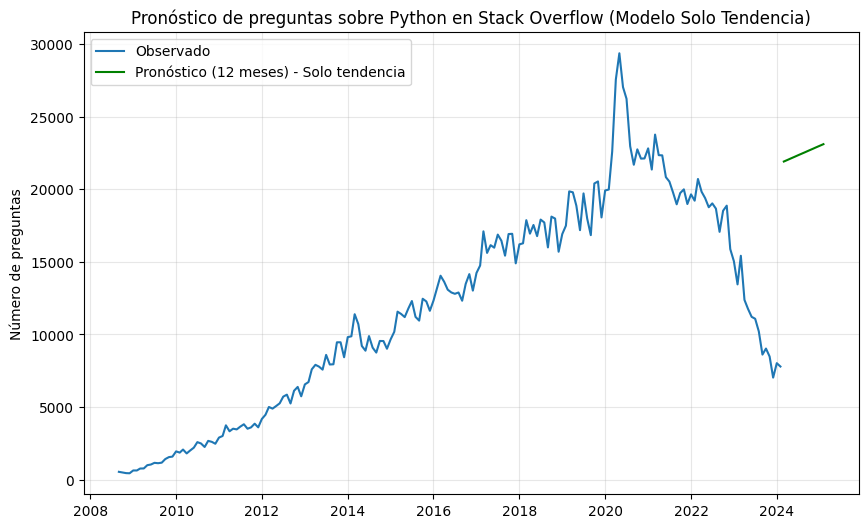

In [37]:
# ahora vamos a crear el modelo de solo tendencia
fit_mco_tendencia = smf.ols("Python ~ trend", data=df_python).fit()


# Pronóstico a 12 meses con el modelo de solo tendencia
pronostico_tendencia = futuro.copy()
pronostico_tendencia["prediccion"] = fit_mco_tendencia.predict(futuro)

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_python["Month"], df_python["Python"], label="Observado")
plt.plot(pronostico_tendencia["Month"], pronostico_tendencia["prediccion"], label="Pronóstico (12 meses) - Solo tendencia", color="green")
plt.title("Pronóstico de preguntas sobre Python en Stack Overflow (Modelo Solo Tendencia)")
plt.ylabel("Número de preguntas")
plt.xlabel("")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



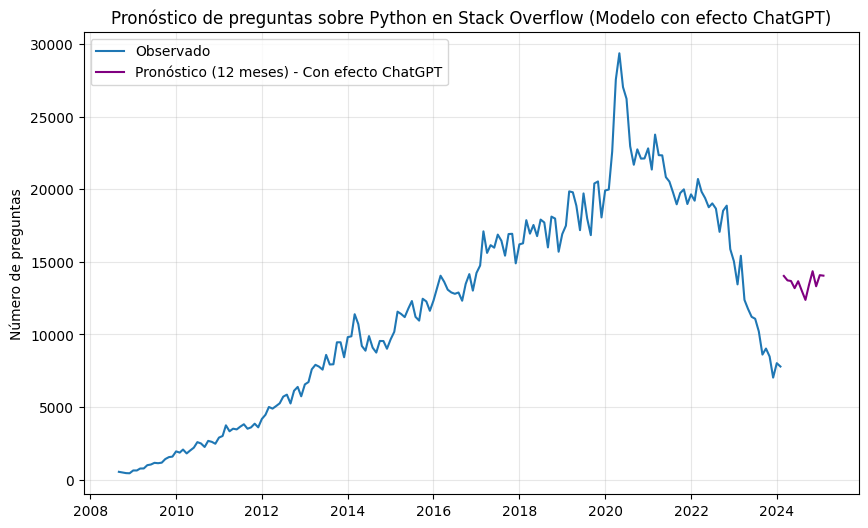

In [38]:
# y hora un modelo donde le demos un valor I de periodo
# el periodo I sera el periodo donde se crea ChatGP que es el 30 de noviembre de 2022

fecha_intervencion = pd.Timestamp("2022-12-01")
I = df_python.index[df_python["Month"] == fecha_intervencion][0]

# dummy de intervención: 1 desde ChatGPT en adelante, 0 antes
df_python["post_chatgpt"] = (df_python["trend"] >= I).astype(int)

fit_mco_chatgpt = smf.ols("Python ~ trend + C(mes) + post_chatgpt", data=df_python).fit()

# pronostico con el modelo que incluye el efecto de ChatGPT
pronostico_chatgpt = futuro.copy()
pronostico_chatgpt["post_chatgpt"] = (pronostico_chatgpt["trend"] >= I).astype(int)
pronostico_chatgpt["prediccion"] = fit_mco_chatgpt.predict(pronostico_chatgpt)

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_python["Month"], df_python["Python"], label="Observado")
plt.plot(pronostico_chatgpt["Month"], pronostico_chatgpt["prediccion"], label="Pronóstico (12 meses) - Con efecto ChatGPT", color="purple")
plt.title("Pronóstico de preguntas sobre Python en Stack Overflow (Modelo con efecto ChatGPT)")
plt.ylabel("Número de preguntas")
plt.xlabel("")  
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [39]:
# bien ahora vamos a comparar los tres modelos con los criterios de R2 ajustado, AIC y BIC
modelos = {
    "Tendencia + Estacionalidad": fit_mco,
    "Tendencia": fit_mco_tendencia,
    "Tendencia + Estacionalidad + Efecto ChatGPT": fit_mco_chatgpt
}

resultados = pd.DataFrame({
    "R2 ajustado": [m.rsquared_adj for m in modelos.values()],
    "AIC": [m.aic for m in modelos.values()],
    "BIC": [m.bic for m in modelos.values()]
}, index=modelos.keys())

resultados

,R2 ajustado,AIC,BIC
Tendencia + Estacionalidad,0.670726,3611.245472,3653.110098
Tendencia,0.677179,3597.052291,3603.493002
Tendencia + Estacionalidad + Efecto ChatGPT,0.906041,3380.170505,3425.255487


#### Conclusiones del modelo

- El modelo con **solo tendencia** presenta un mejor desempeño que el de **tendencia + estacionalidad**, según el R² ajustado y los criterios AIC y BIC, lo que indica que la estacionalidad no aporta información relevante adicional.

- La inclusión del **efecto ChatGPT** mejora sustancialmente el ajuste del modelo, elevando el R² ajustado a más de 0.90 y reduciendo notablemente el AIC y BIC.

- Esto sugiere que el cambio estructural asociado a la aparición de ChatGPT explica una parte significativa del comportamiento de la serie, superando ampliamente a la estacionalidad tradicional.

In [40]:
# ahora vamos a medir el rendimiento del pronóstico de los tres modelos
# lo mediremos con MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), MAPE (Mean Absolute Percentage Error) y MASE (Mean Absolute Scaled Error)

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# MASE
""" 
MASE requiere una función personalizada porque no está implementada en sklearn
La funcion basicamente calcula el error absoluto medio escalado (MASE) 
"""
def mean_absolute_scaled_error(y_true, y_pred, y_train):
    y_train = np.asarray(y_train)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    d = np.mean(np.abs(np.diff(y_train))) #error medio absoluto de la serie de entrenamiento
    if d == 0:
        return np.nan 

    return np.mean(np.abs(y_true - y_pred) / d) # retorna el error absoluto medio escalado (MASE)


# Función general para evaluar modelo
def evaluar_modelo(y_test, y_pred, y_train):
    return {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "MASE": mean_absolute_scaled_error(y_test, y_pred, y_train)
    }

# Train / Test split (80 / 20)
train_size = int(len(df_python) * 0.8)

y_train = df_python["Python"].iloc[:train_size]
y_test = df_python["Python"].iloc[train_size:]

X_train = df_python[["trend", "mes", "post_chatgpt"]].iloc[:train_size]
X_test = df_python[["trend", "mes", "post_chatgpt"]].iloc[train_size:]

# Predicciones
y_pred_mco = fit_mco.predict(X_test)
y_pred_tendencia = fit_mco_tendencia.predict(X_test[["trend"]])
y_pred_chatgpt = fit_mco_chatgpt.predict(X_test)

# evaluacion de los modelos
resultados_pronostico = pd.DataFrame.from_dict({
    "Tendencia + Estacionalidad":
        evaluar_modelo(y_test, y_pred_mco, y_train),

    "Tendencia":
        evaluar_modelo(y_test, y_pred_tendencia, y_train),

    "Tendencia + Estacionalidad + ChatGPT":
        evaluar_modelo(y_test, y_pred_chatgpt, y_train),
}, orient="index")

resultados_pronostico



,MAE,RMSE,MAPE,MASE
Tendencia + Estacionalidad,4992.984880,6775.643059,0.464343,6.823174
Tendencia,5059.397969,6935.631513,0.472979,6.913930
Tendencia + Estacionalidad + ChatGPT,2896.630668,3452.010783,0.204306,3.958396


#### Conclusiones del desempeño predictivo

- El modelo con **tendencia + estacionalidad + efecto ChatGPT** presenta un desempeño claramente superior en todas las métricas de error (MAE, RMSE, MAPE y MASE).

- La inclusión del **efecto ChatGPT reduce el error absoluto y relativo en más de un 40%** respecto a los modelos basados únicamente en tendencia o en tendencia más estacionalidad.

- Los modelos sin el efecto ChatGPT exhiben errores elevados y muy similares entre sí, lo que confirma que la **estacionalidad aporta pocas mejoras al pronóstico**.

- Estos resultados indican que el cambio estructural asociado a la aparición de ChatGPT es un **factor clave para explicar y predecir el comportamiento reciente de la serie**, superando ampliamente a los componentes tradicionales.

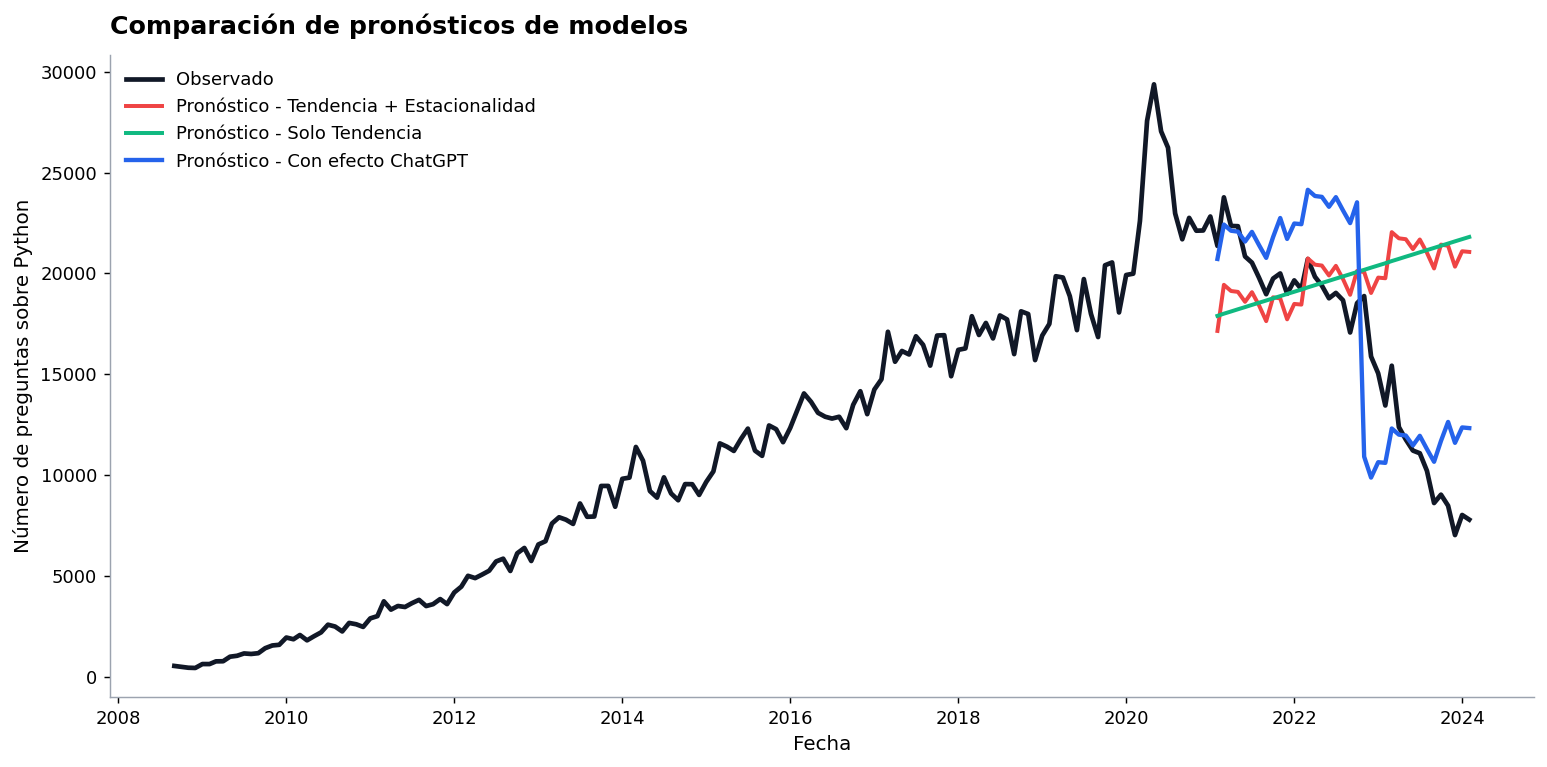

In [41]:
# grafico con los 3 modelos
fechas_test = df_python.loc[X_test.index, "Month"]

fig, ax = plt.subplots(figsize=(12, 6), dpi=130)

# serie observada completa
ax.plot(
    df_python["Month"],
    df_python["Python"],
    label="Observado",
    color="#111827",
    linewidth=2.6
)

# pronosticos en periodo de test
ax.plot(
    fechas_test,
    y_pred_mco,
    label="Pronóstico - Tendencia + Estacionalidad",
    color="#ef4444",
    linewidth=2.2
)
ax.plot(
    fechas_test,
    y_pred_tendencia,
    label="Pronóstico - Solo Tendencia",
    color="#10b981",
    linewidth=2.2
)
ax.plot(
    fechas_test,
    y_pred_chatgpt,
    label="Pronóstico - Con efecto ChatGPT",
    color="#2563eb",
    linewidth=2.4
)

# formato profesional
ax.set_title("Comparación de pronósticos de modelos", loc="left", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Fecha", fontsize=11)
ax.set_ylabel("Número de preguntas sobre Python", fontsize=11)

# eje X más limpio
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", labelrotation=0)
ax.tick_params(axis="both", labelsize=10)

# quitar cuadricula y bordes innecesarios
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# bordes visibles con tono suave
ax.spines["left"].set_color("#9ca3af")
ax.spines["bottom"].set_color("#9ca3af")

# leyenda limpia
ax.legend(frameon=False, ncol=1, fontsize=10, loc="upper left")

plt.tight_layout()
plt.show()

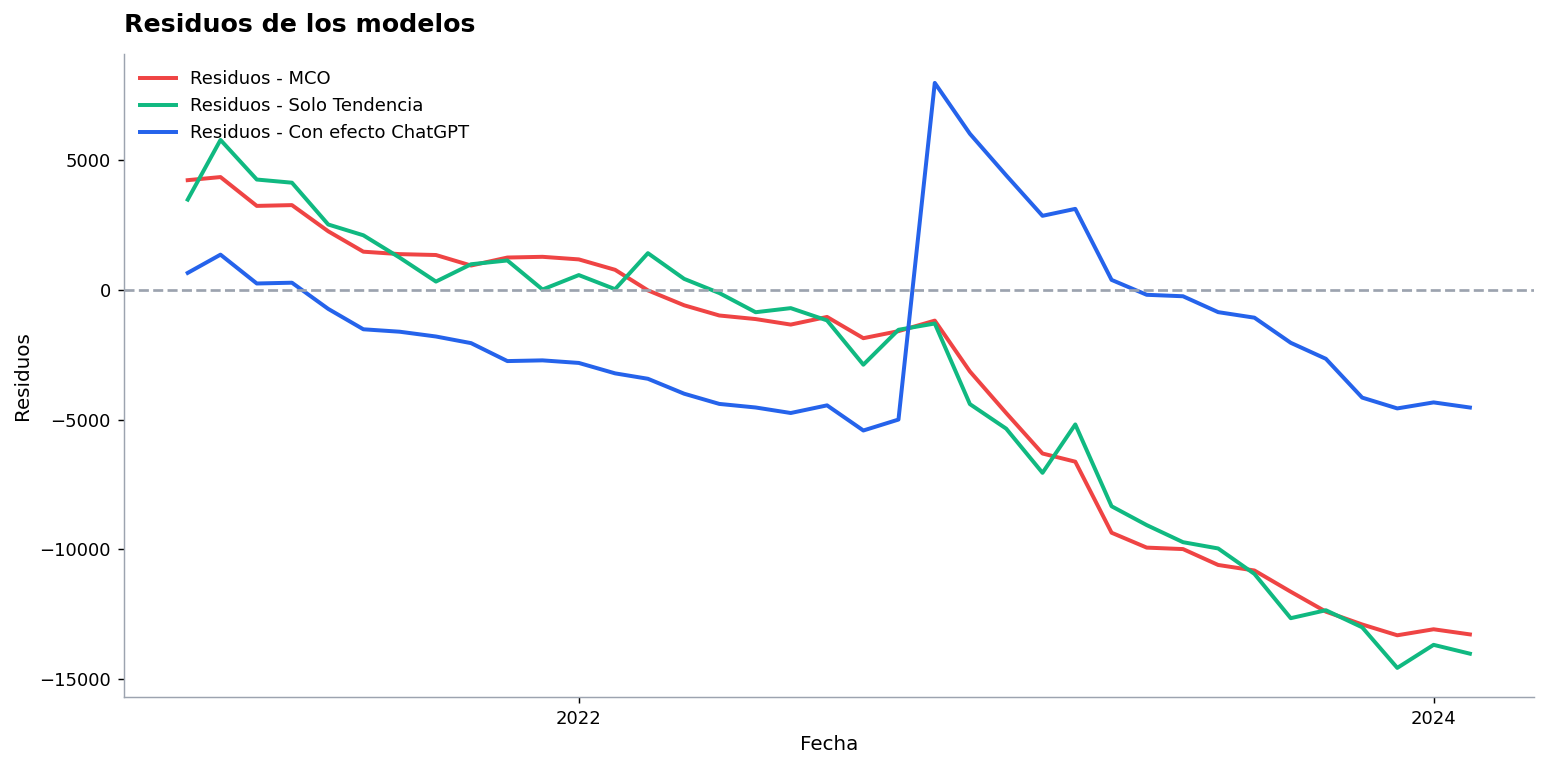

In [42]:
# por ultimo vamos a ver los residuos de todos los modelos para ver si cumplen con los supuestos de los errores
residuos_mco = y_test - y_pred_mco
residuos_tendencia = y_test - y_pred_tendencia
residuos_chatgpt = y_test - y_pred_chatgpt

# grafico de los residuos de todos los modelos
fig, ax = plt.subplots(figsize=(12, 6), dpi=130)
ax.plot(fechas_test, residuos_mco, label="Residuos - MCO", color="#ef4444", linewidth=2.2)
ax.plot(fechas_test, residuos_tendencia, label="Residuos - Solo Tendencia", color="#10b981", linewidth=2.2)
ax.plot(fechas_test, residuos_chatgpt, label="Residuos - Con efecto ChatGPT", color="#2563eb", linewidth=2.2)
ax.axhline(0, color="#9ca3af", linestyle="--", linewidth=1.5)

# formato profesional
ax.set_title("Residuos de los modelos", loc="left", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Fecha", fontsize=11)
ax.set_ylabel("Residuos", fontsize=11)

# eje X más limpio
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", labelrotation=0)
ax.tick_params(axis="both", labelsize=10)

# quitar cuadricula y bordes innecesarios
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# bordes visibles con tono suave
ax.spines["left"].set_color("#9ca3af")
ax.spines["bottom"].set_color("#9ca3af")

# leyenda limpia
ax.legend(frameon=False, ncol=1, fontsize=10, loc="upper left")

plt.tight_layout()
plt.show()

#### Interpretación de residuos con tendencia

Como los residuos de un modelo presentan una tendencia clara, esto indica que el modelo no ha capturado adecuadamente la estructura de largo plazo de la serie. En consecuencia, los errores no son puramente aleatorios y parte de la información sistemática permanece sin explicar, lo que sugiere una mala especificación del modelo y posibles problemas en la inferencia y el pronóstico.

Los residuos con el efecto ChatGPT muestran una tendencia mucho menos pronunciada, lo que indica que este modelo ha capturado mejor la estructura de largo plazo de la serie. Sin embargo, aún se observa cierta tendencia residual, lo que sugiere que podría haber otros factores o cambios estructurales no considerados que siguen afectando el comportamiento de la serie. En general, aunque el modelo con efecto ChatGPT mejora significativamente la captura de la tendencia, aún podría beneficiarse de una especificación más completa para eliminar completamente la tendencia en los residuos.

